<a href="https://colab.research.google.com/github/INTROESPACIAL20261/pantilla0/blob/main/trabajo_final2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
myEstate="2910 27th Ave W, Seattle, WA 98199"

La propiedad es un **Private room in rental unit** de **un dormitorio**.

## El problema

> ¿Cuánto se puede cobrar por la unidad?

## El criterio

> Se utilizarán los precios de unidades similares ubicadas dentro de un radio de 500 metros.

## Preparación

### Instalaciones

Se usarán las mismas librerías del modelo:

- **PYSAL / Tobler** para la interpolación espacial.
- **H3** para crear una cuadrícula hexagonal.

In [48]:
!pip install pysal h3

### Los datos

Se trabajará con los límites de los vecindarios de Seattle y con los anuncios publicados por Inside Airbnb.

In [49]:
import pandas as pd
import geopandas as gpd


linkSeattleBorder="https://data.insideairbnb.com/united-states/wa/seattle/2025-09-25/visualisations/neighbourhoods.geojson"
seattle=gpd.read_file(linkSeattleBorder).to_crs(32610)

linkSeattleAirbnb="https://data.insideairbnb.com/united-states/wa/seattle/2025-09-25/data/listings.csv.gz"
airbnb_all=pd.read_csv(linkSeattleAirbnb)

El GeoDataFrame **seattle** contiene los polígonos de los vecindarios y se encuentra proyectado en metros.

In [50]:
seattle

,neighbourhood,neighbourhood_group,geometry
0,Wallingford,Other neighborhoods,"MULTIPOLYGON (((549001.097 5279274.997, 549065..."
1,West Queen Anne,Queen Anne,"MULTIPOLYGON (((548303.038 5276444.716, 548303..."
2,Adams,Ballard,"MULTIPOLYGON (((546811.936 5280469.799, 546821..."
3,West Woodland,Ballard,"MULTIPOLYGON (((546811.936 5280469.799, 546831..."
4,East Queen Anne,Queen Anne,"MULTIPOLYGON (((548303.038 5276444.716, 548303..."
...,...,...,...
86,Highland Park,Delridge,"MULTIPOLYGON (((549493.784 5265413.992, 549546..."
87,Madison Park,Capitol Hill,"MULTIPOLYGON (((553113.887 5276733.128, 553124..."
88,Stevens,Capitol Hill,"MULTIPOLYGON (((551560.756 5276066.849, 551560..."
89,Broadview,Other neighborhoods,"MULTIPOLYGON (((546527.714 5284532.032, 546532..."


Por otro lado, **airbnb_all** es un DataFrame con varias columnas.

In [51]:
airbnb_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6996 entries, 0 to 6995
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            6996 non-null   int64  
 1   listing_url                                   6996 non-null   object 
 2   scrape_id                                     6996 non-null   int64  
 3   last_scraped                                  6996 non-null   object 
 4   source                                        6996 non-null   object 
 5   name                                          6996 non-null   object 
 6   description                                   6879 non-null   object 
 7   neighborhood_overview                         4176 non-null   object 
 8   picture_url                                   6996 non-null   object 
 9   host_id                                       6996 non-null   i

Se conservarán las mismas columnas relevantes utilizadas en el modelo.

In [52]:
keep=['id','price','bedrooms','property_type','latitude','longitude']
airbnb=airbnb_all[keep].copy()
airbnb.head()

,id,price,bedrooms,property_type,latitude,longitude
0,6606,$99.00,1.0,Entire guesthouse,47.65444,-122.33629
1,9419,$71.00,1.0,Private room in rental unit,47.55017,-122.31937
2,9596,NaN,1.0,Entire rental unit,47.65608,-122.33602
3,11012,$311.00,3.0,Entire home,47.65405,-122.33744
4,25002,$88.00,1.0,Entire guest suite,47.67947,-122.37196


Se revisan nuevamente los tipos de datos.

In [53]:
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6996 entries, 0 to 6995
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             6996 non-null   int64  
 1   price          6221 non-null   object 
 2   bedrooms       6845 non-null   float64
 3   property_type  6996 non-null   object 
 4   latitude       6996 non-null   float64
 5   longitude      6996 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 328.1+ KB


La columna **price** debe limpiarse y convertirse a tipo numérico.

In [54]:
airbnb.price.str.replace(r'\$|\,', '', regex=True).astype(float)

,price
0,99.0
1,71.0
2,NaN
3,311.0
4,88.0
...,...
6991,58.0
6992,58.0
6993,88.0
6994,132.0


Se aplica el cambio y se eliminan los datos faltantes.

In [55]:
#then

airbnb['price']=airbnb.price.str.replace(r'\$|\,', '', regex=True).astype(float)
# bye missing data
airbnb.dropna(inplace=True)

# check
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6210 entries, 0 to 6995
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             6210 non-null   int64  
 1   price          6210 non-null   float64
 2   bedrooms       6210 non-null   float64
 3   property_type  6210 non-null   object 
 4   latitude       6210 non-null   float64
 5   longitude      6210 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 339.6+ KB


Utilizando el número de dormitorios y el tipo de propiedad, se seleccionan las unidades similares.

In [56]:
pd.crosstab(airbnb.property_type,airbnb.bedrooms)

bedrooms,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,11.0,13.0
property_type,,,,,,,,,,,,
Barn,0,1,0,0,0,0,0,0,0,0,0,0
Boat,0,0,2,0,0,0,0,0,0,0,0,0
Camper/RV,0,2,0,0,0,0,0,0,0,0,0,0
Casa particular,0,1,0,0,0,0,0,0,0,0,0,0
Castle,0,1,0,0,0,0,0,0,0,0,0,0
Entire bungalow,2,7,13,2,1,0,0,0,0,0,0,0
Entire cabin,0,2,0,0,0,0,0,0,0,0,0,0
Entire condo,53,296,144,8,3,0,0,0,0,0,0,0
Entire cottage,3,22,13,4,0,0,0,0,0,0,0,0


Se aplica el filtro correspondiente.

In [57]:
conditionText="bedrooms==1 & property_type=='Private room in rental unit'"
airbnb_source=airbnb.query(conditionText).copy()
airbnb_source

,id,price,bedrooms,property_type,latitude,longitude
1,9419,71.0,1.0,Private room in rental unit,47.550170,-122.319370
12,226677,71.0,1.0,Private room in rental unit,47.549710,-122.317530
24,365550,109.0,1.0,Private room in rental unit,47.600020,-122.327420
74,1012003,149.0,1.0,Private room in rental unit,47.639480,-122.322360
171,2830174,72.0,1.0,Private room in rental unit,47.594850,-122.309500
...,...,...,...,...,...,...
6842,1490573123465704226,45.0,1.0,Private room in rental unit,47.630359,-122.371875
6912,1504717028999105706,45.0,1.0,Private room in rental unit,47.630195,-122.371857
6927,1506084988374594013,45.0,1.0,Private room in rental unit,47.629120,-122.371720
6941,1508873967130263918,33.0,1.0,Private room in rental unit,47.606313,-122.330507


Se convierte el DataFrame de Airbnb en un GeoDataFrame.

Primero, se eliminan las unidades con coordenadas duplicadas.

In [58]:
# Create a list of columns that must be identical to be considered a duplicate
key_columns = ['latitude', 'longitude']

# Remove rows that are identical across the key columns
airbnb_source_unique = airbnb_source.drop_duplicates(subset=key_columns)

Luego se convierte a GeoDataFrame.

In [59]:
airbnb_source_gdf = gpd.GeoDataFrame(
    airbnb_source_unique,
    geometry=gpd.points_from_xy(airbnb_source_unique.longitude,
                                airbnb_source_unique.latitude),
    crs='EPSG:4326') #long / lat



airbnb_source_gdf=airbnb_source_gdf.to_crs(seattle.crs)

Se muestran las dos capas.

<Axes: >

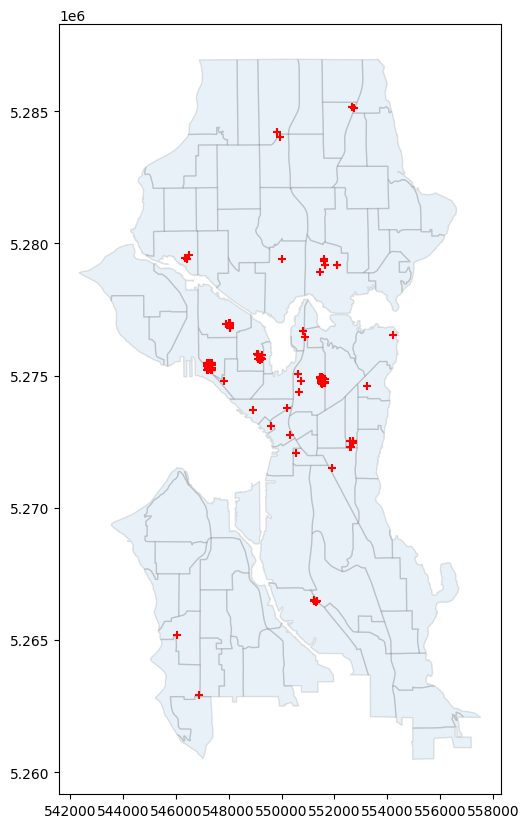

In [60]:
base=seattle.plot(figsize=(10,10),alpha=0.1,edgecolor='black')
airbnb_source_gdf.plot(ax=base,marker="+",color='red')

## La necesidad de una interpolación espacial

Se conocen los precios y las ubicaciones de las unidades similares, pero no se conoce el precio que correspondería a la dirección seleccionada.

### Creación de la cuadrícula objetivo

Se utilizará una cuadrícula hexagonal H3 de resolución 10, igual que en el modelo.

In [61]:
import tobler

# this gives a warning, no worries
tobler.util.h3fy(seattle, resolution=10)

,geometry
hex_id,
8a28d5572347fff,"POLYGON ((547686.252 5266051.388, 547633.286 5..."
8a28d5546517fff,"POLYGON ((545385.807 5267354.293, 545332.847 5..."
8a28d5551817fff,"POLYGON ((546106.48 5270171.755, 546053.53 527..."
8a28d5570da7fff,"POLYGON ((547495.702 5263511.513, 547442.728 5..."
8a28d5572a2ffff,"POLYGON ((547598.895 5265376.715, 547545.927 5..."
...,...
8a28d555461ffff,"POLYGON ((548742.646 5268870.461, 548689.69 52..."
8a28d555099ffff,"POLYGON ((548423.679 5269305.821, 548370.724 5..."
8a28d5550c57fff,"POLYGON ((548776.571 5269743.007, 548723.617 5..."


In [62]:
# this gives no warning, but NOT really needed:
seattle_grid10=tobler.util.h3fy(seattle.to_crs(4326), resolution=10).to_crs(seattle.crs)

La resolución 10 es apropiada para representar pequeñas áreas urbanas.

In [63]:
seattle_target_locations = seattle_grid10.centroid.get_coordinates()
seattle_target_locations.head()

,x,y
hex_id,,
8a28d5572347fff,547704.039463,5.265985e+06
8a28d5546517fff,545403.579744,5.267288e+06
8a28d5551817fff,546124.253749,5.270106e+06
8a28d5570da7fff,547513.491326,5.263445e+06
8a28d5572a2ffff,547616.682594,5.265311e+06


Los precios se estimarán en los centroides de los hexágonos.

### Métodos de estimación

Se organizan los datos de entrada.

Estas son las coordenadas de las unidades de Airbnb.

In [64]:
airbnb_source_locations = airbnb_source_gdf.get_coordinates()
airbnb_source_locations

,x,y
1,551211.620979,5.266530e+06
12,551350.514101,5.266480e+06
24,550557.921041,5.272065e+06
74,550899.964626,5.276454e+06
171,551910.077400,5.271502e+06
...,...,...
6842,547188.906759,5.275409e+06
6912,547190.477725,5.275390e+06
6927,547201.701386,5.275271e+06
6941,550319.866941,5.272762e+06


Estos son los precios conocidos.

In [65]:
airbnb_source_gdf.price

,price
1,71.0
12,71.0
24,109.0
74,149.0
171,72.0
...,...
6842,45.0
6912,45.0
6927,45.0
6941,33.0


Esta es la cuadrícula objetivo.

In [66]:
seattle_target_locations

,x,y
hex_id,,
8a28d5572347fff,547704.039463,5.265985e+06
8a28d5546517fff,545403.579744,5.267288e+06
8a28d5551817fff,546124.253749,5.270106e+06
8a28d5570da7fff,547513.491326,5.263445e+06
8a28d5572a2ffff,547616.682594,5.265311e+06
...,...,...
8a28d555461ffff,548760.436614,5.268804e+06
8a28d555099ffff,548441.466766,5.269240e+06
8a28d5550c57fff,548794.360756,5.269677e+06


Los datos anteriores contienen coordenadas proyectadas. Se mantienen los métodos del modelo para comparar resultados.

- **Método 1:** se utiliza el precio de la unidad similar más cercana.

<Axes: >

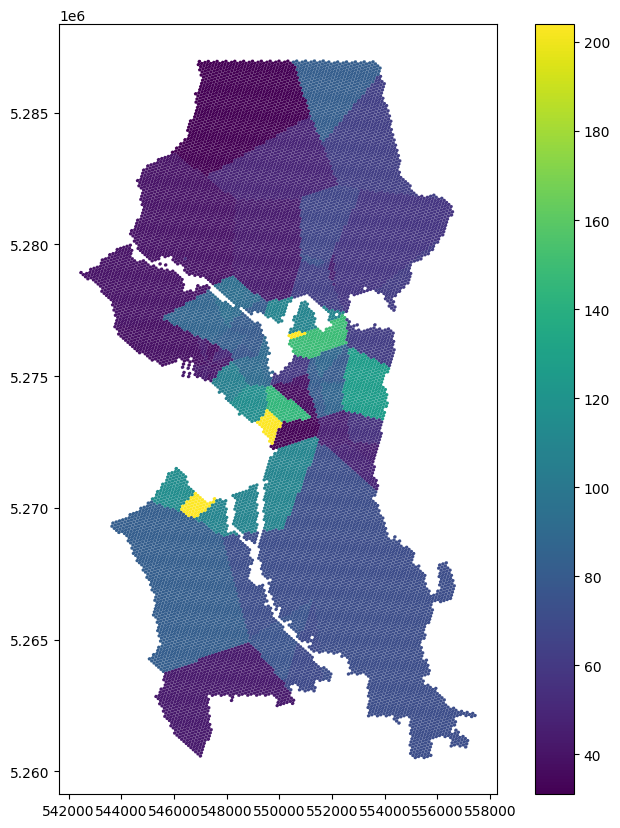

In [67]:
from scipy.interpolate import griddata

seattle_grid10["nearest"] = griddata(points=airbnb_source_locations,
                                    values=airbnb_source_gdf.price,
                                    xi=seattle_target_locations,
                                    method="nearest")

seattle_grid10.plot("nearest", legend=True,figsize=(10,10))

- **Método 2:** se utiliza el promedio de las diez unidades similares más cercanas.

<Axes: >

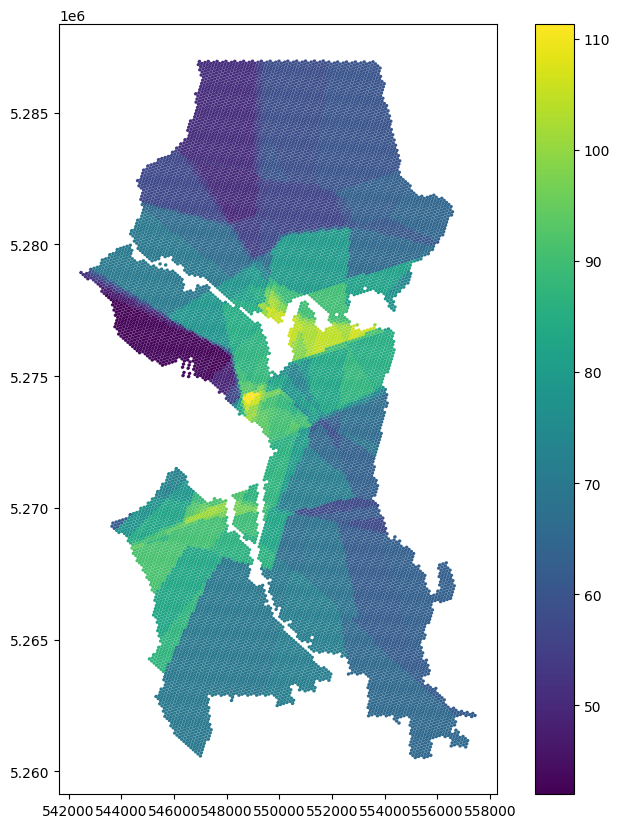

In [68]:
from sklearn.neighbors import KNeighborsRegressor

interpolation_uniform = KNeighborsRegressor(n_neighbors=10,
                                            weights="uniform").\
                                            fit(airbnb_source_locations,
                                                airbnb_source_gdf.price)

seattle_grid10["knn10_uniform"] = interpolation_uniform.predict(seattle_target_locations)

seattle_grid10.plot("knn10_uniform", legend=True,figsize=(10,10))

<Axes: >

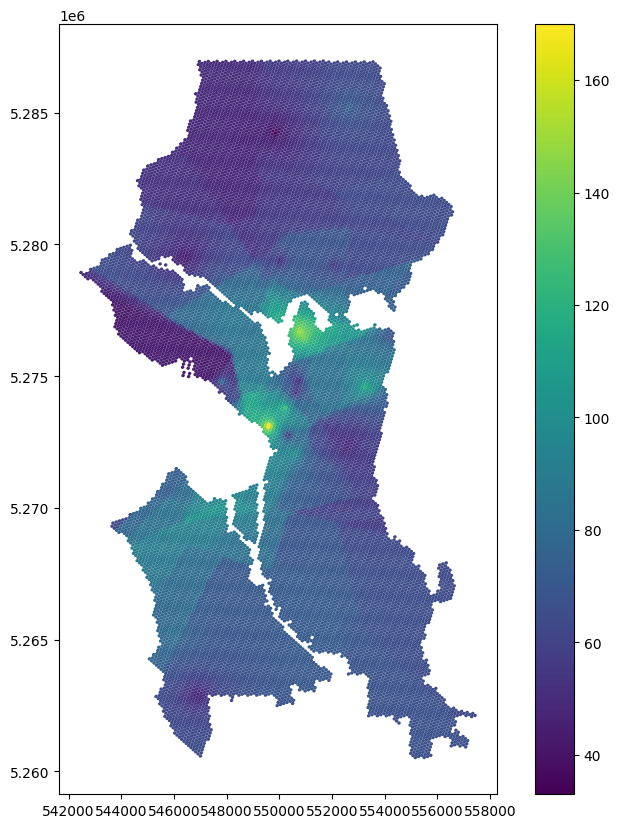

In [69]:
interpolation_IDW = KNeighborsRegressor(n_neighbors=10,
                                            weights="distance").\
                                            fit(airbnb_source_locations,
                                                airbnb_source_gdf.price)

seattle_grid10["IDW_10"] = interpolation_IDW.predict(seattle_target_locations)

seattle_grid10.plot("IDW_10", legend=True,figsize=(10,10))

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_regression.py:508: UserWarning: One or more samples have no neighbors within specified radius; predicting NaN.
  warnings.warn(empty_warning_msg)


<Axes: >

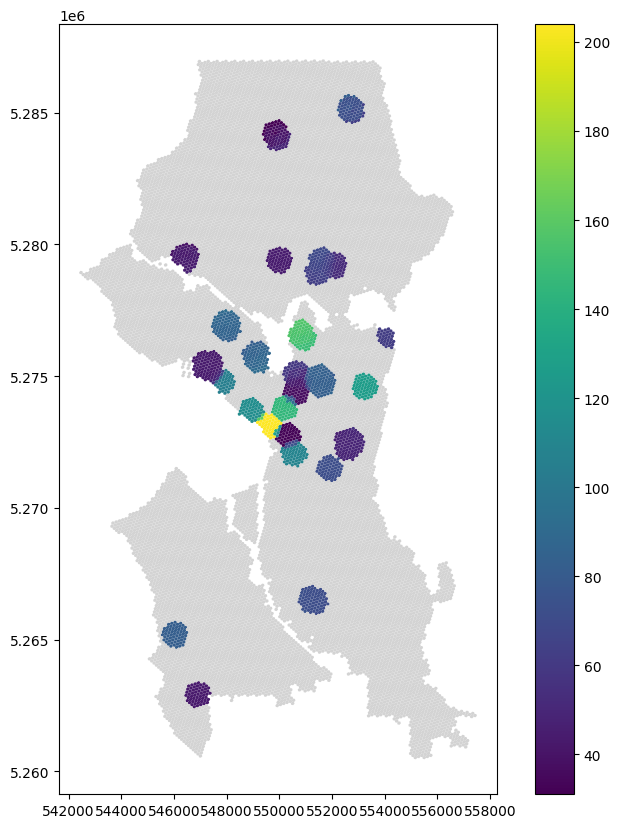

In [70]:
from sklearn.neighbors import RadiusNeighborsRegressor

interpolation_radius = RadiusNeighborsRegressor(
    radius=500, weights="distance"
)
interpolation_radius.fit(
    airbnb_source_locations, airbnb_source_gdf.price
)

seattle_grid10["radius_500"] = interpolation_radius.predict(seattle_target_locations)

seattle_grid10.plot("radius_500", legend=True, missing_kwds={'color': 'lightgrey'},figsize=(10,10))

## ¿Cuánto se debería cobrar?



In [71]:
from geopy.geocoders import Nominatim
from shapely.geometry import Point

geolocator = Nominatim(user_agent="theGeocoder")

myEstate_Address = geolocator.geocode(myEstate)

# see
myEstate_Address

Location(2910, 27th Avenue West, Southeast Magnolia, Magnolia, Seattle, King County, Washington, 98199, United States, (47.646235, -122.3912405, 0.0))

El resultado de **geolocator.geocode** contiene la dirección, longitud y latitud.

In [72]:
myEstate_Address.address, myEstate_Address.longitude,myEstate_Address.latitude

('2910, 27th Avenue West, Southeast Magnolia, Magnolia, Seattle, King County, Washington, 98199, United States',
 -122.3912405,
 47.646235)

Se crea un GeoDataFrame con la ubicación de la propiedad.

In [73]:
myEstats_gdf4326 = gpd.GeoDataFrame(
    {'address': [myEstate_Address.address]},
    geometry=[Point(myEstate_Address.longitude, myEstate_Address.latitude)],
    crs="EPSG:4326" # because of lon/lat
)

# reprojecting
myEstats_gdf = myEstats_gdf4326.to_crs(seattle.crs)

# here it is
myEstats_gdf

,address,geometry
0,"2910, 27th Avenue West, Southeast Magnolia, Ma...",POINT (545720.228 5277161.427)


Finalmente, se identifica el hexágono en el que se encuentra la propiedad y se recuperan los precios estimados.

In [74]:
myEstats_gdf.sjoin(
    seattle_grid10,
    how="left",
    predicate="within"
)

,address,geometry,hex_id,nearest,knn10_uniform,IDW_10,radius_500
0,"2910, 27th Avenue West, Southeast Magnolia, Ma...",POINT (545720.228 5277161.427),8a28d547412ffff,87.0,57.3,57.456699,NaN


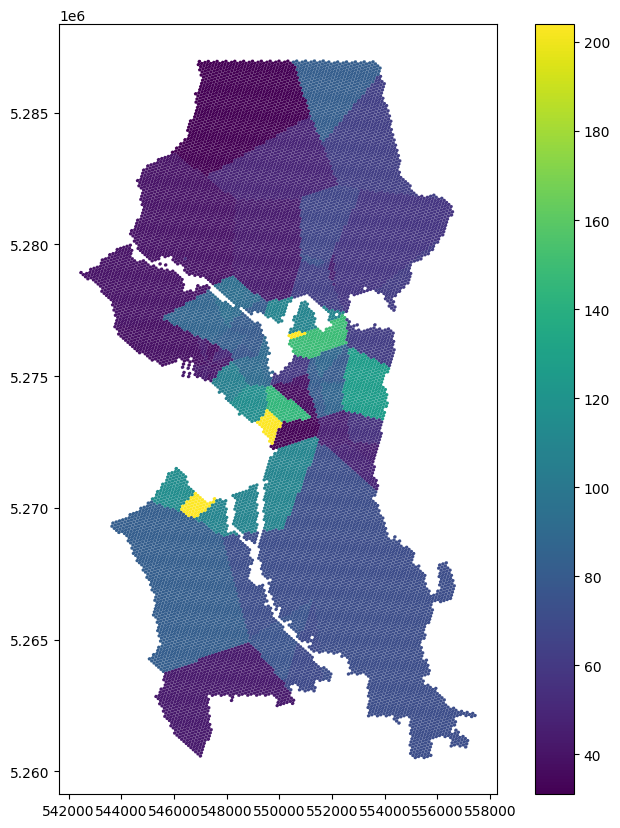

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

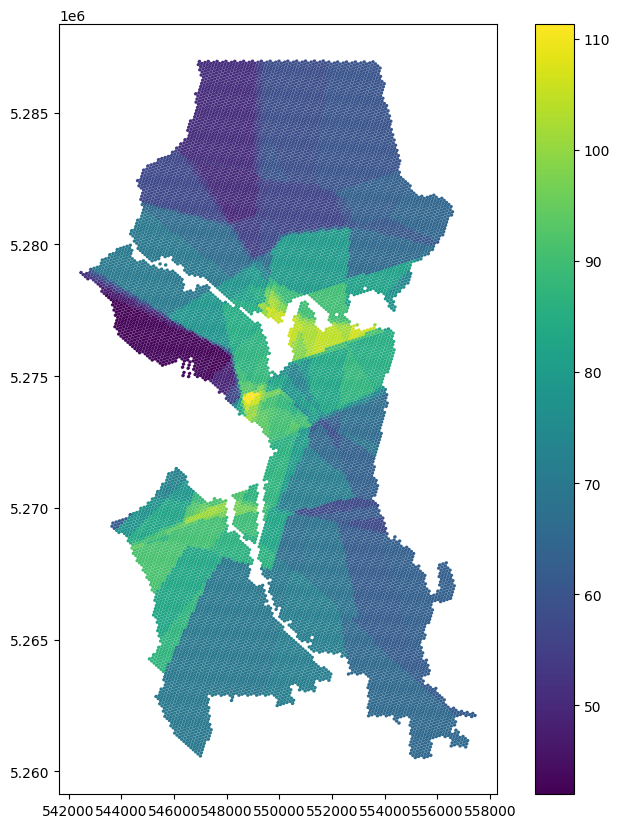

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

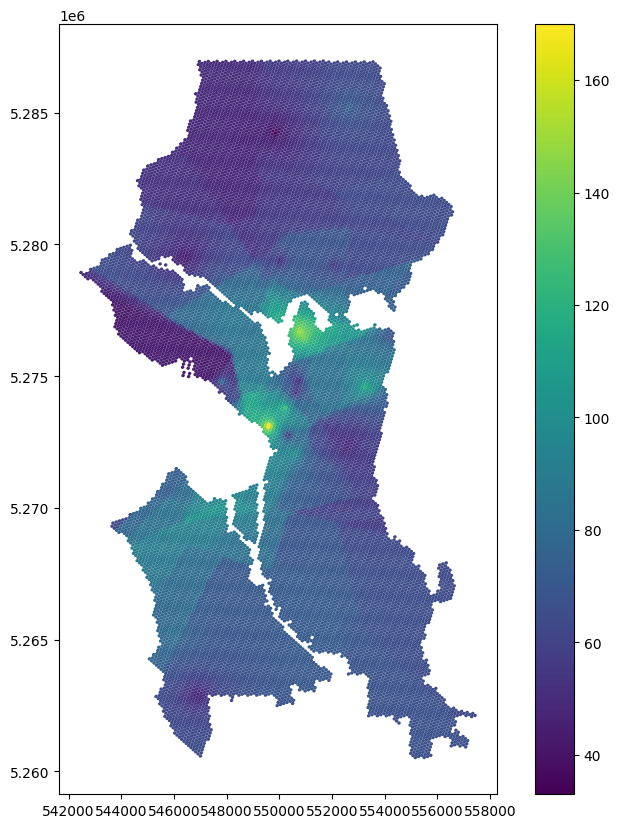

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [75]:
import matplotlib.pyplot as plt
from google.colab import files
seattle_grid10.plot(
    "nearest",
    legend=True,
    figsize=(10,10)
)

plt.savefig(
    "mapa_nearest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

files.download("mapa_nearest.png")

seattle_grid10.plot(
    "knn10_uniform",
    legend=True,
    figsize=(10,10)
)

plt.savefig(
    "mapa_knn10_uniform.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

files.download("mapa_knn10_uniform.png")

seattle_grid10.plot(
    "IDW_10",
    legend=True,
    figsize=(10,10)
)

plt.savefig(
    "mapa_IDW_10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

files.download("mapa_IDW_10.png")

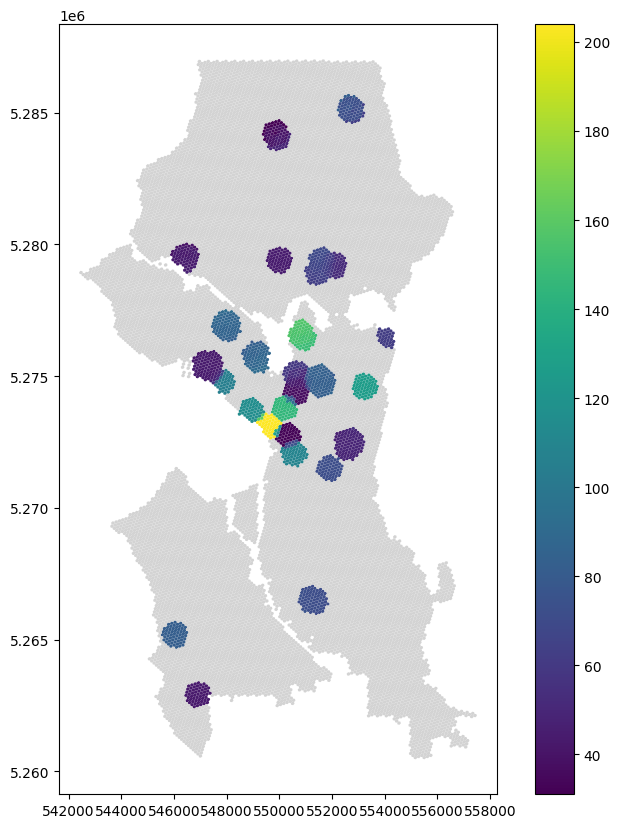

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [77]:
seattle_grid10.plot(
    "radius_500",
    legend=True,
    missing_kwds={'color': 'lightgrey'},
    figsize=(10,10)
)

plt.savefig(
    "mapa_final_python.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

files.download("mapa_final_python.png")

## Decisión final

La tabla resultante presenta cuatro estimaciones:

| Método | Interpretación |
|---|---|
| `nearest` | Precio de la unidad similar más cercana |
| `knn10_uniform` | Promedio de las 10 unidades similares más cercanas |
| `IDW_10` | Promedio ponderado por distancia de las 10 unidades más cercanas |
| `radius_500` | Precio estimado usando las unidades similares ubicadas dentro de 500 metros |

Debido a que la consigna exige utilizar como único criterio las unidades similares situadas dentro de un radio de 500 metros, la recomendación final será el valor que aparezca en la columna **`radius_500`**.

El mapa final en Python es el producido en la sección del método **radius_500**. Ese resultado y la recomendación obtenida se utilizarán posteriormente en el Flexdashboard de R.

______

Trabajo adaptado a Seattle siguiendo la estructura y el código del modelo proporcionado.